# Phase - 1

In [4]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project


In [5]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

from models.events import EVENT_MAPPING, SHORT_EVENTS, MAJOR_EVENTS, COUNTRY_YEAR_EVENTS

plt.style.use("seaborn-v0_8-whitegrid")
sns.set(font_scale=1.1)
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")

In [7]:
OUTPUT_DIR = Path("../worldbank_tableau_project/outputs/Event_overlay_2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('../worldbank_tableau_project/outputs/Event_overlay_2')

In [8]:
f_df = pd.read_csv("data/feature_engineered_data.csv")

ind_clusters = pd.read_csv("data/indicator_clusters.csv")

country_clusters = pd.read_csv("data/2_df_traj_clusters.csv")

anomaly_df = pd.read_csv("data/anomaly_df.csv")


In [9]:
ind_clusters.columns

Index(['indicator_name', 'spike_count', 'dip_count', 'avg_volatility',
       'slope_mean', 'momentum_mean', 'coef_variation', 'cagr_mean',
       'regional_dev_std', 'global_event_count', 'country_event_count',
       'category', 'PC1', 'PC2', 'indicator_cluster', 'cluster_name'],
      dtype='object')

In [10]:
country_clusters.columns

Index(['country_name', 'cat_Demographics_trend_slope',
       'cat_Economy_trend_slope', 'cat_Education_trend_slope',
       'cat_Governance_trend_slope', 'cat_Health_trend_slope',
       'cat_Labor_trend_slope', 'cat_LegalAutonomy_trend_slope',
       'cat_WBL_trend_slope', 'cat_Demographics_cagr', 'cat_Economy_cagr',
       'cat_Education_cagr', 'cat_Governance_cagr', 'cat_Health_cagr',
       'cat_Labor_cagr', 'cat_WBL_cagr', 'cat_Demographics_momentum',
       'cat_Economy_momentum', 'cat_Education_momentum',
       'cat_Governance_momentum', 'cat_Health_momentum', 'cat_Labor_momentum',
       'cat_LegalAutonomy_momentum', 'cat_WBL_momentum',
       'cat_Demographics_rolling_std_5y', 'cat_Economy_rolling_std_5y',
       'cat_Education_rolling_std_5y', 'cat_Governance_rolling_std_5y',
       'cat_Health_rolling_std_5y', 'cat_Labor_rolling_std_5y',
       'cat_WBL_rolling_std_5y', 'cat_Demographics_spike', 'cat_Economy_spike',
       'cat_Education_spike', 'cat_Governance_spike', 'ca

In [11]:
anomaly_df.columns.to_list()

['country_name',
 'Cluster',
 'Cluster_Name',
 'PC1',
 'PC2',
 'PC3',
 'iso_raw_score',
 'iso_anomaly_score',
 'iso_label',
 'Anomaly_Driver']

In [12]:
# Start from base panel
df = f_df.copy()

# --- 1) Merge indicator clusters ---
# Keep your original names + add a clearer alias for narrative use
ind_clusters_renamed = ind_clusters.rename(
    columns={"cluster_name": "indicator_cluster_name"}
)

df = df.merge(
    ind_clusters_renamed[["indicator_name", "indicator_cluster", "indicator_cluster_name"]],
    on="indicator_name",
    how="left"
)



df = df.merge(
    country_clusters[["country_name", "traj_cluster", "Cluster_Name", "traj_cluster"]],
    on="country_name",
    how="left"
)

# --- 3) Merge anomaly dataframe ---
# We don't assume specific column names; we just bring everything in.
# If there are overlapping column names, they'll get a "_anomaly" suffix.
df = df.merge(
    anomaly_df,
    on="country_name",
    how="left",
    suffixes=("", "_anomaly")
)

print(df.shape)
df.head()


(18144, 43)


,country_name,year,value,indicator_id,indicator_name,unit_type,source,source_reliable,region,category,...,traj_cluster,Cluster,Cluster_Name_anomaly,PC1,PC2,PC3,iso_raw_score,iso_anomaly_score,iso_label,Anomaly_Driver
0,Algeria,2000,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,...,1,3,North African Reformers,-0.837744,0.597726,-1.528005,0.087545,-0.087545,0,PC3
1,Algeria,2001,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,...,1,3,North African Reformers,-0.837744,0.597726,-1.528005,0.087545,-0.087545,0,PC3
2,Algeria,2002,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,...,1,3,North African Reformers,-0.837744,0.597726,-1.528005,0.087545,-0.087545,0,PC3
3,Algeria,2003,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,...,1,3,North African Reformers,-0.837744,0.597726,-1.528005,0.087545,-0.087545,0,PC3
4,Algeria,2004,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,...,1,3,North African Reformers,-0.837744,0.597726,-1.528005,0.087545,-0.087545,0,PC3


In [13]:
# --- Add Legal Autonomy category ---
legal_autonomy_inds = [
    'A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
    'A woman can be "head of household" in the same way as a man (1=yes; 0=no)',
    'A woman can choose where to live in the same way as a man (1=yes; 0=no)',
    'A woman can get a job in the same way as a man (1=yes; 0=no)',
    'A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no)',
    'A woman can open a bank account in the same way as a man (1=yes; 0=no)',
    'A woman can register a business in the same way as a man (1=yes; 0=no)',
    'A woman can sign a contract in the same way as a man (1=yes; 0=no)',
    'A woman can travel outside her home in the same way as a man (1=yes; 0=no)',
    'A woman can travel outside the country in the same way as a man (1=yes; 0=no)',
    'A woman can work at night in the same way as a man (1=yes; 0=no)',
    'A woman can work in a job deemed dangerous in the same way as a man (1=yes; 0=no)',
    'A woman can work in an industrial job in the same way as a man (1=yes; 0=no)',
    'A woman has the same rights to remarry as a man (1=yes; 0=no)'
]

df.loc[df["indicator_name"].isin(legal_autonomy_inds), "category"] = "LegalAutonomy"

df.loc[
    df["indicator_name"] == "Women, Business and the Law: Pension Indicator Score (scale 1-100)",
    "category"
] = "WBL"

df.loc[
    df["indicator_name"] == 
    "Criminal penalties or civil remedies exist for sexual harassment in employment (1=yes; 0=no)",
    "category"
] = "Governance"

In [14]:
df.isna().sum()

country_name                  0
year                          0
value                         0
indicator_id                  0
indicator_name                0
unit_type                     0
source                        0
source_reliable               0
region                        0
category                      0
val_num                       0
yoy_change                  756
yoy_pct_change            11215
yoy_pct_exists                0
rolling_mean_3y               0
rolling_std_3y             6966
rolling_mean_5y               0
rolling_std_5y             6966
cagr                       8295
spike                         0
dip                           0
outlier                       0
trend_slope                   0
coef_variation             3144
momentum                   5643
regional_deviation            0
regional_deviation_std        0
event_global               3024
event_country             15582
indicator_cluster             0
indicator_cluster_name        0
traj_clu

In [15]:
df['category'].value_counts()

category
LegalAutonomy    6048
WBL              3888
Labor            2592
Health           1728
Demographics     1296
Governance       1296
Economy           864
Education         432
Name: count, dtype: int64

In [16]:
# Basic NA check on key identifiers
key_cols = ["country_name", "year", "indicator_id", "indicator_name", "category"]
df[key_cols].isna().sum()


country_name      0
year              0
indicator_id      0
indicator_name    0
category          0
dtype: int64

In [17]:
# Ensure correct dtypes
df["year"] = df["year"].astype(int)
df["country_name"] = df["country_name"].astype(str)
df["indicator_name"] = df["indicator_name"].astype(str)
df["category"] = df["category"].astype(str)

# Spike / dip as 0/1 ints (if not already)
for col in ["spike", "dip"]:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)


In [18]:
# --- Global event flags ---
def has_global_event(year: int) -> int:
    return int(
        (year in EVENT_MAPPING)
        or (year in MAJOR_EVENTS)
        or (year in SHORT_EVENTS)
    )

df["event_global"] = df["year"].apply(has_global_event)

# --- Country-specific event flags ---
def has_country_event(row) -> int:
    key_exact = (row["country_name"], row["year"])
    key_all   = ("All", row["year"])
    return int(key_exact in COUNTRY_YEAR_EVENTS or key_all in COUNTRY_YEAR_EVENTS)

df["event_country"] = df.apply(has_country_event, axis=1)

# --- Names / labels from dictionaries ---

df["global_event_name"] = df["year"].map(EVENT_MAPPING).fillna("")
df["major_event_name"]  = df["year"].map(MAJOR_EVENTS).fillna("")
df["short_event"]       = df["year"].map(SHORT_EVENTS).fillna("")

def get_country_event_name(row):
    key_exact = (row["country_name"], row["year"])
    key_all   = ("All", row["year"])
    if key_exact in COUNTRY_YEAR_EVENTS:
        return COUNTRY_YEAR_EVENTS[key_exact]
    if key_all in COUNTRY_YEAR_EVENTS:
        return COUNTRY_YEAR_EVENTS[key_all]
    return ""

df["country_event_name"] = df.apply(get_country_event_name, axis=1)


In [19]:
df["event_global"].value_counts()



event_global
1    15120
0     3024
Name: count, dtype: int64

In [20]:
df["event_country"].value_counts()


event_country
0    15582
1     2562
Name: count, dtype: int64

In [21]:
df[df.event_country == 1][["country_name","year"]].drop_duplicates()

,country_name,year
5,Algeria,2005
15,Algeria,2015
19,Algeria,2019
20,Algeria,2020
22,Algeria,2022
...,...,...
15142,United Arab Emirates,2022
16148,West Bank and Gaza,2020
16150,West Bank and Gaza,2022
17156,"Yemen, Rep.",2020


In [22]:
df.isna().sum().sort_values(ascending=False).head(20)

yoy_pct_change            11215
cagr                       8295
rolling_std_5y             6966
rolling_std_3y             6966
momentum                   5643
coef_variation             3144
yoy_change                  756
Cluster_Name_anomaly          0
indicator_cluster             0
indicator_cluster_name        0
traj_cluster                  0
Cluster_Name                  0
traj_cluster                  0
Cluster                       0
PC1                           0
event_global                  0
PC2                           0
PC3                           0
iso_raw_score                 0
iso_anomaly_score             0
dtype: int64

In [23]:
# Any volatility in this row?
df["has_spike_or_dip"] = ((df["spike"] == 1) | (df["dip"] == 1)).astype(int)

# Any kind of event?
df["has_any_event"] = ((df["event_global"] == 1) | (df["event_country"] == 1)).astype(int)

def combine_event_labels(row):
    labels = []

    for col in ["short_event", "major_event_name", "global_event_name", "country_event_name"]:
        val = str(row[col]).strip()
        if val and val.lower() != "none":
            labels.append(val)

    # keep unique in order
    seen = set()
    uniq = []
    for l in labels:
        if l not in seen:
            uniq.append(l)
            seen.add(l)

    return "; ".join(uniq)

df["event_label_combined"] = df.apply(combine_event_labels, axis=1)

# Anomaly flag (if any anomaly column exists)
anomaly_cols = [c for c in df.columns if "anomaly" in c.lower() or "anomal" in c.lower()]
if anomaly_cols:
    # treat any non-null anomaly-related value as "has anomaly"
    df["has_anomaly"] = df[anomaly_cols].notna().any(axis=1).astype(int)
else:
    df["has_anomaly"] = 0

# Quick sanity look
df[[
    "country_name", "year", "indicator_name",
    "spike", "dip",
    "event_global", "event_country",
    "event_label_combined", "has_anomaly"
]].head(10)


,country_name,year,indicator_name,spike,dip,event_global,event_country,event_label_combined,has_anomaly
0,Algeria,2000,A woman can apply for a passport in the same w...,0,0,0,0,,1
1,Algeria,2001,A woman can apply for a passport in the same w...,0,0,1,0,9/11 Attacks,1
2,Algeria,2002,A woman can apply for a passport in the same w...,0,0,0,0,,1
3,Algeria,2003,A woman can apply for a passport in the same w...,0,0,1,0,Iraq War Begins,1
4,Algeria,2004,A woman can apply for a passport in the same w...,0,0,1,0,Morocco Family Code Reform; Free Trade with US...,1
5,Algeria,2005,A woman can apply for a passport in the same w...,0,0,1,1,Syrian Withdrawal from Lebanon; Algeria Nation...,1
6,Algeria,2006,A woman can apply for a passport in the same w...,0,0,1,0,Lebanon-Israel War,1
7,Algeria,2007,A woman can apply for a passport in the same w...,0,0,0,0,,1
8,Algeria,2008,A woman can apply for a passport in the same w...,0,0,1,0,Global Financial Crisis,1
9,Algeria,2009,A woman can apply for a passport in the same w...,0,0,0,0,,1


# PHASE 2

## 2.1 VOLATILITY EXPLORATION

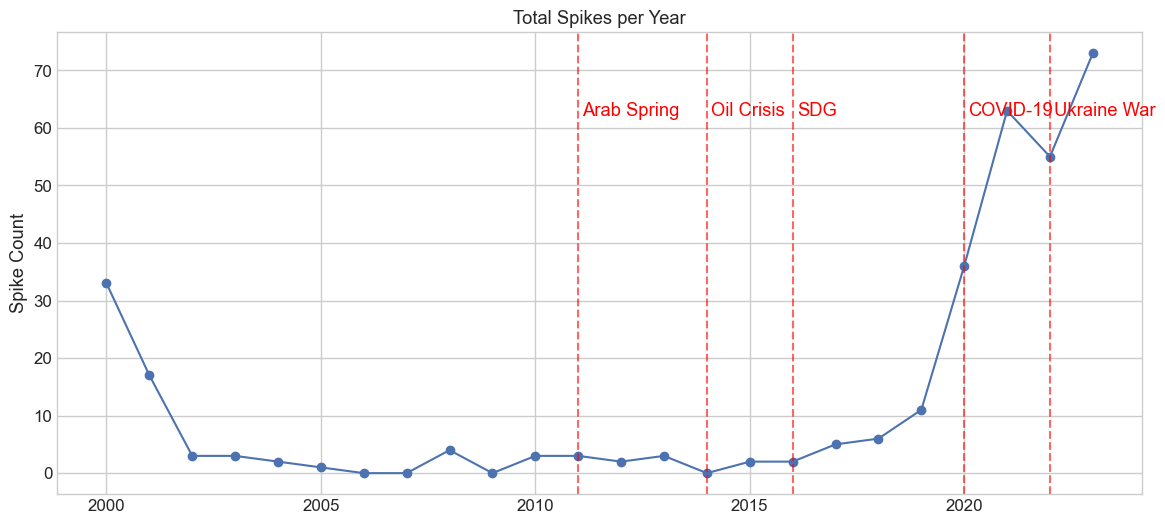

In [24]:
# --- Spike counts by year ---
spikes_by_year = df.groupby("year")["spike"].sum()

plt.figure(figsize=(14,6))
plt.plot(spikes_by_year.index, spikes_by_year.values, marker="o")
plt.title("Total Spikes per Year")
plt.ylabel("Spike Count")
plt.grid(True)

for year, label in SHORT_EVENTS.items():
    if year in spikes_by_year.index:
        plt.axvline(year, color="red", linestyle="--", alpha=0.6)
        plt.text(year+0.1, spikes_by_year.max()*0.85, label, color="red")

plt.show()


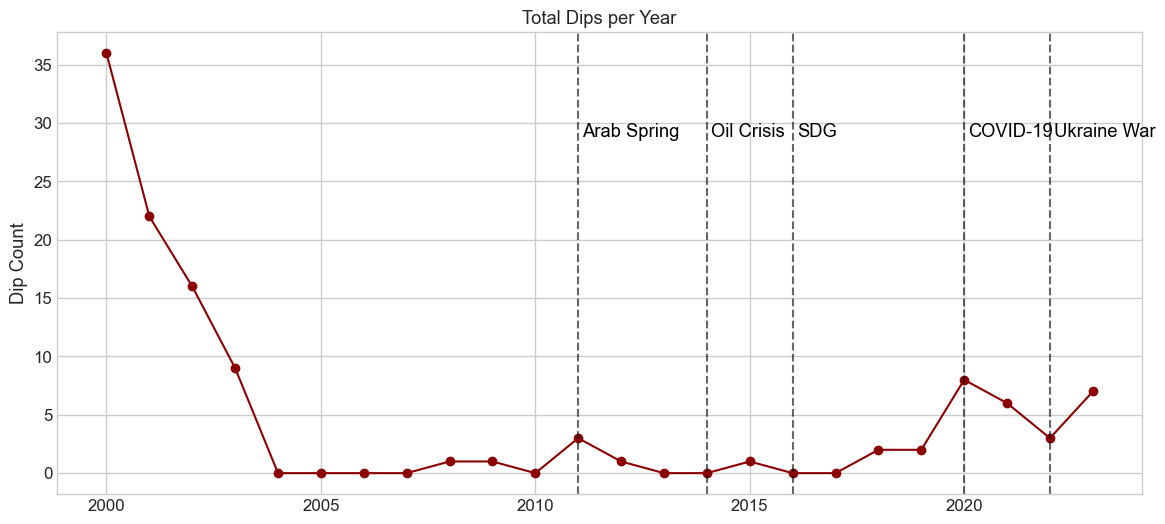

In [25]:
dips_by_year = df.groupby("year")["dip"].sum()

plt.figure(figsize=(14,6))
plt.plot(dips_by_year.index, dips_by_year.values, marker="o", color="darkred")
plt.title("Total Dips per Year")
plt.ylabel("Dip Count")
plt.grid(True)

for year, label in SHORT_EVENTS.items():
    if year in dips_by_year.index:
        plt.axvline(year, color="black", linestyle="--", alpha=0.6)
        plt.text(year+0.1, dips_by_year.max()*0.8, label, color="black")

plt.show()


## 2.2 CATEGORY-LEVEL SHOCK RESPONSE

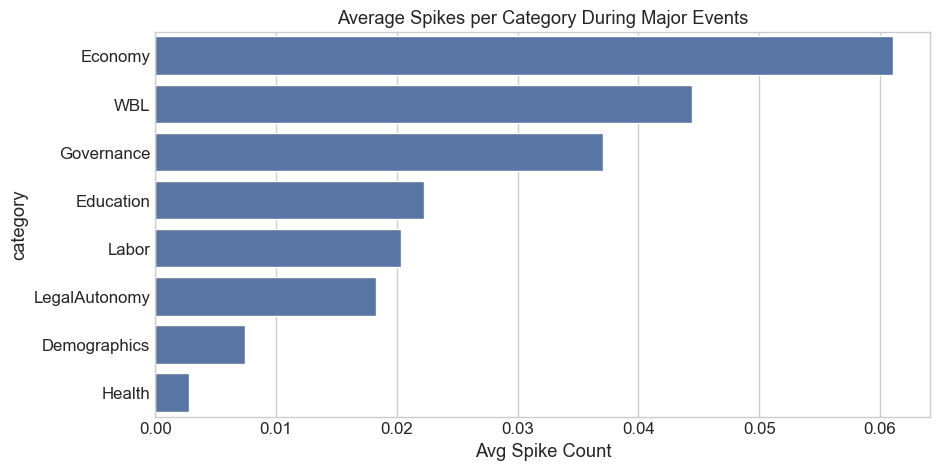

In [26]:
event_years = list(SHORT_EVENTS.keys())

cat_event_spikes = (
    df[df["year"].isin(event_years)]
    .groupby("category")["spike"].mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(x=cat_event_spikes.values, y=cat_event_spikes.index)
plt.title("Average Spikes per Category During Major Events")
plt.xlabel("Avg Spike Count")
plt.show()


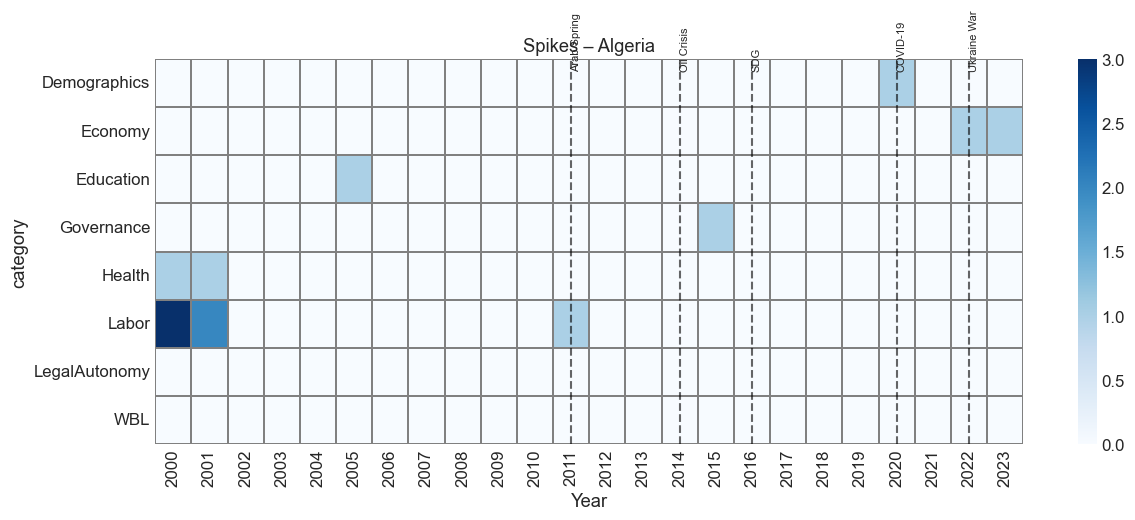

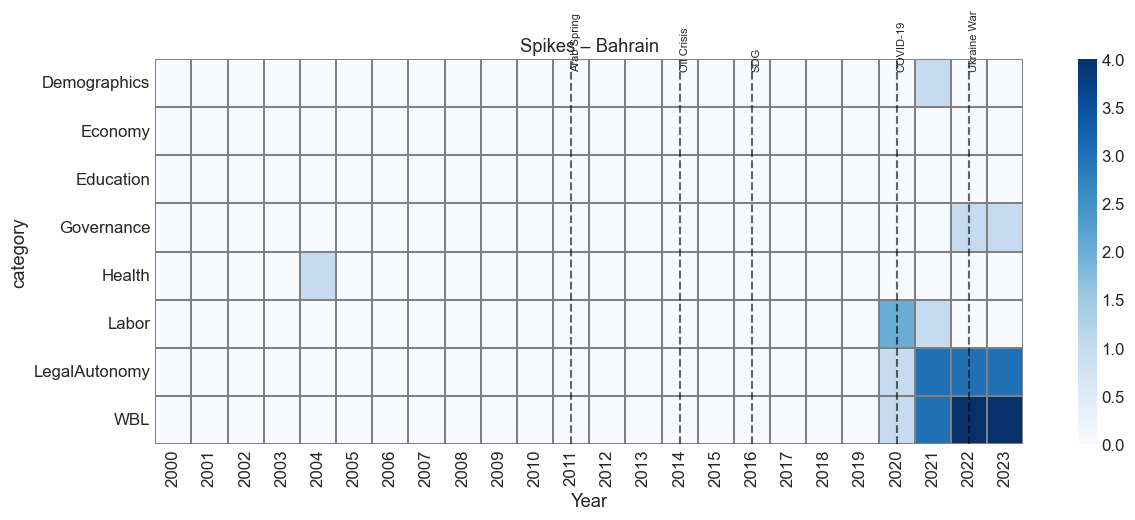

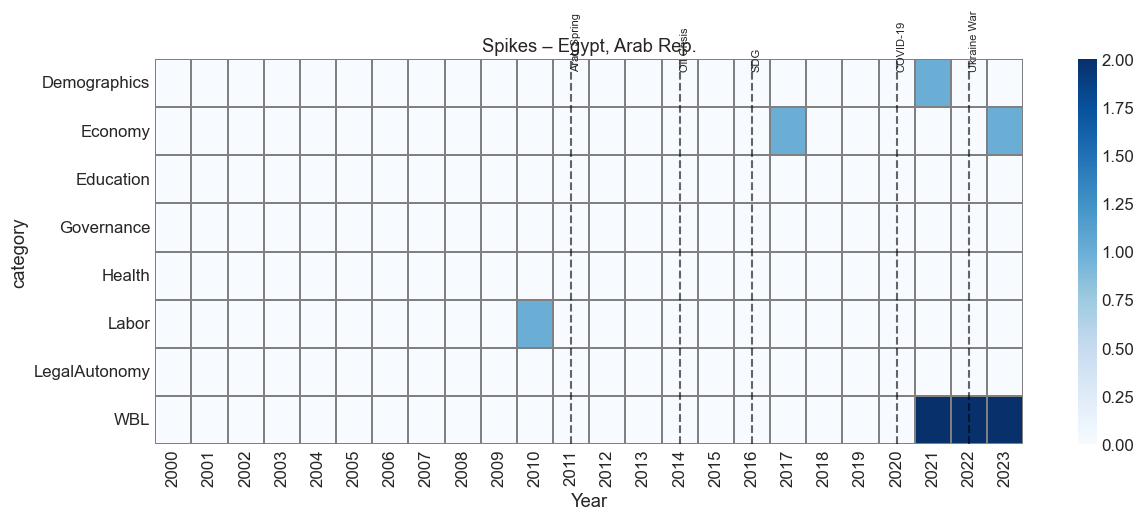

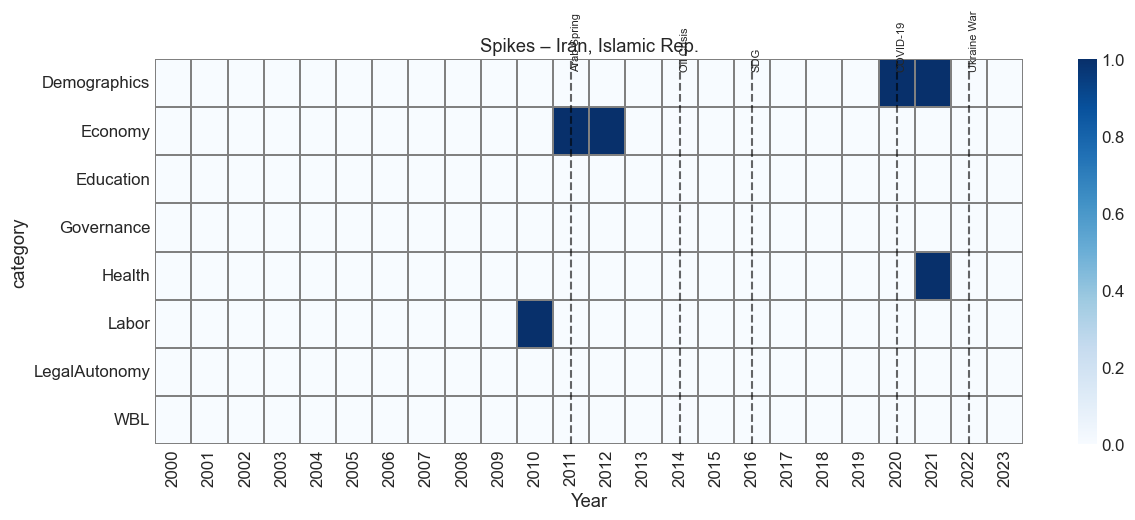

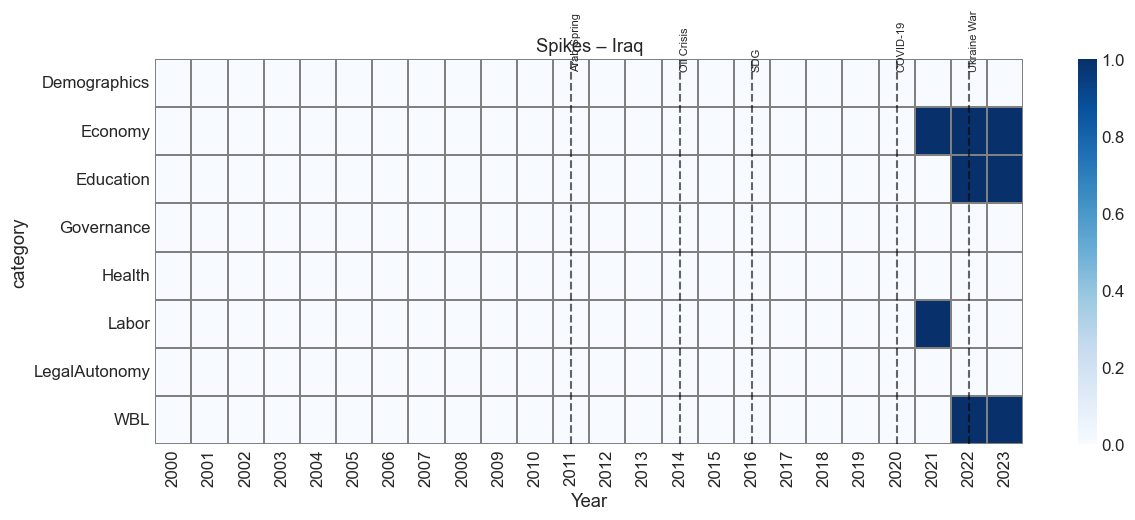

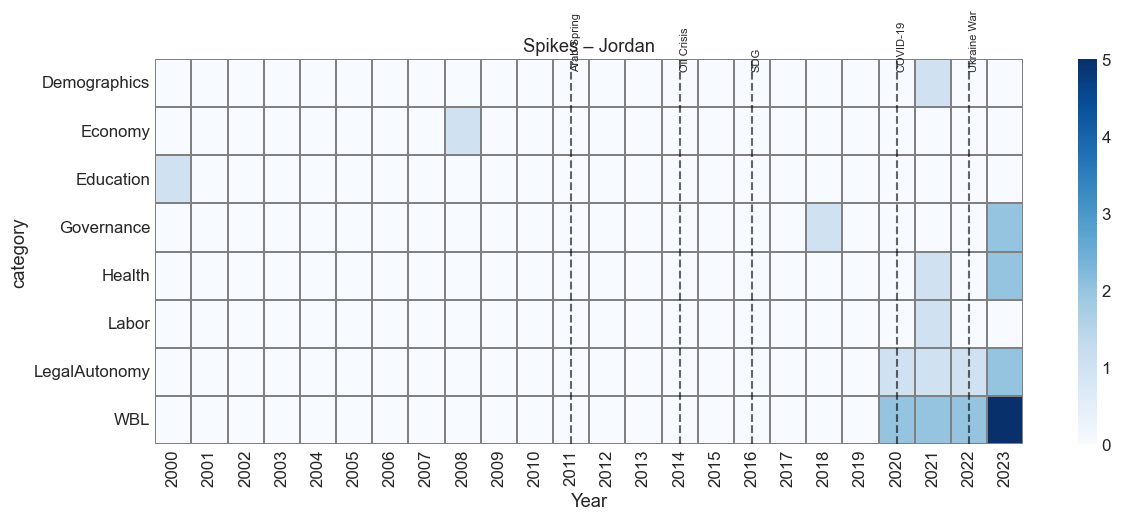

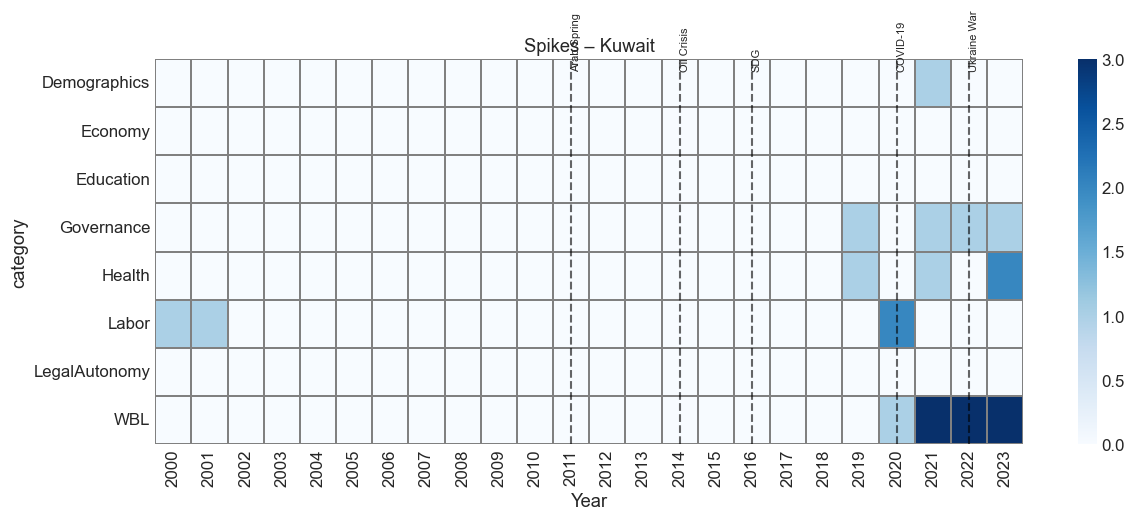

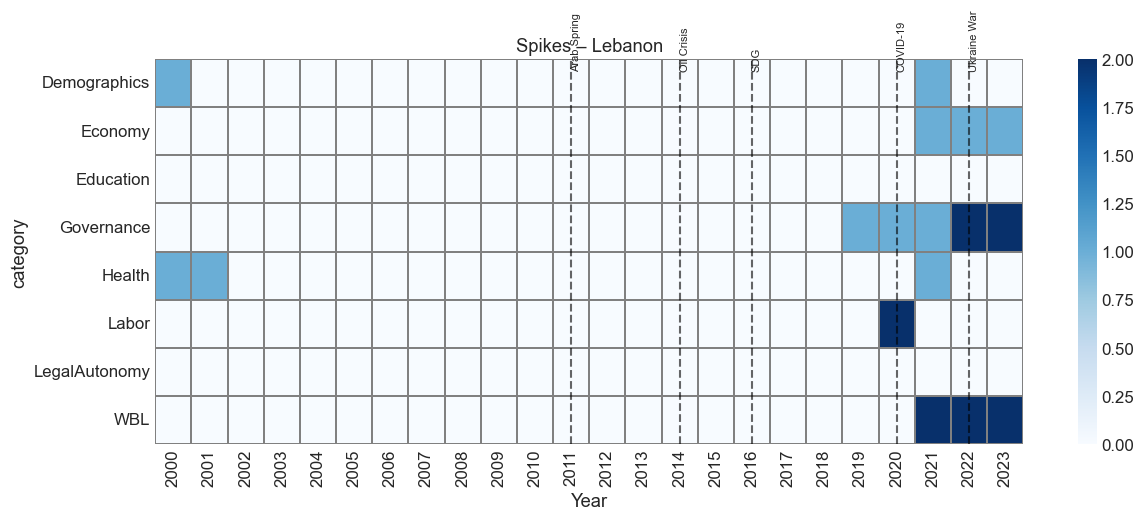

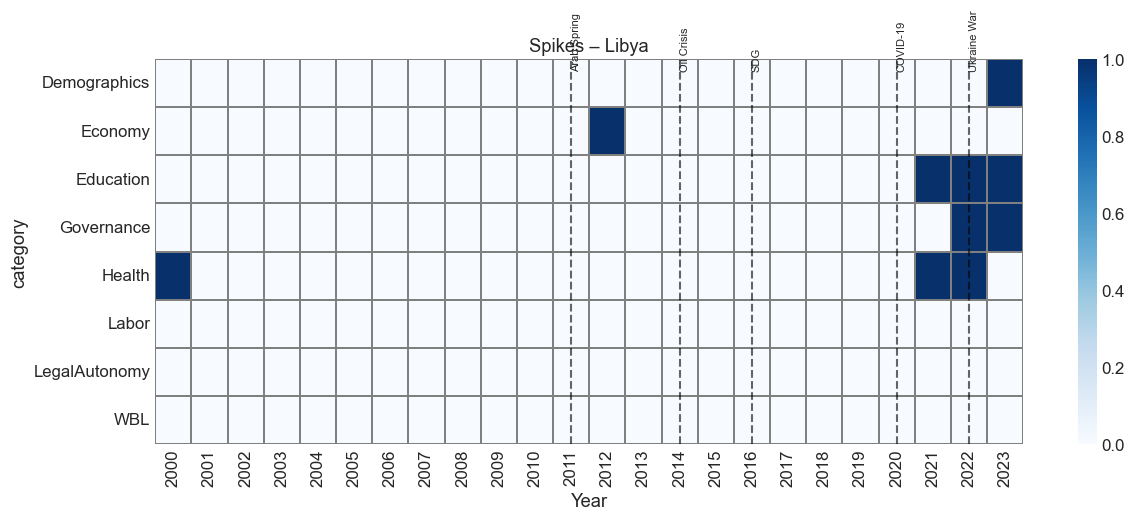

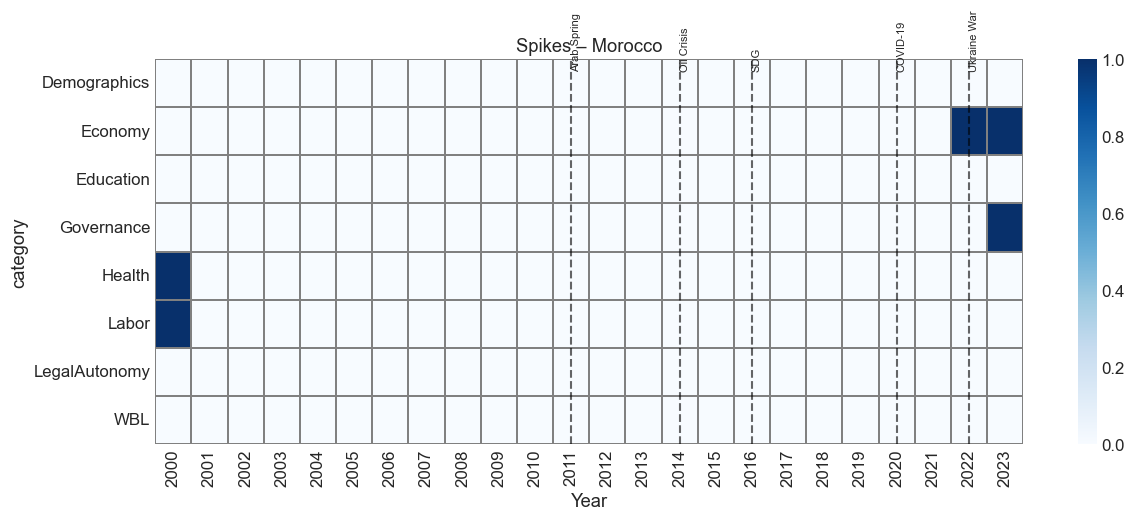

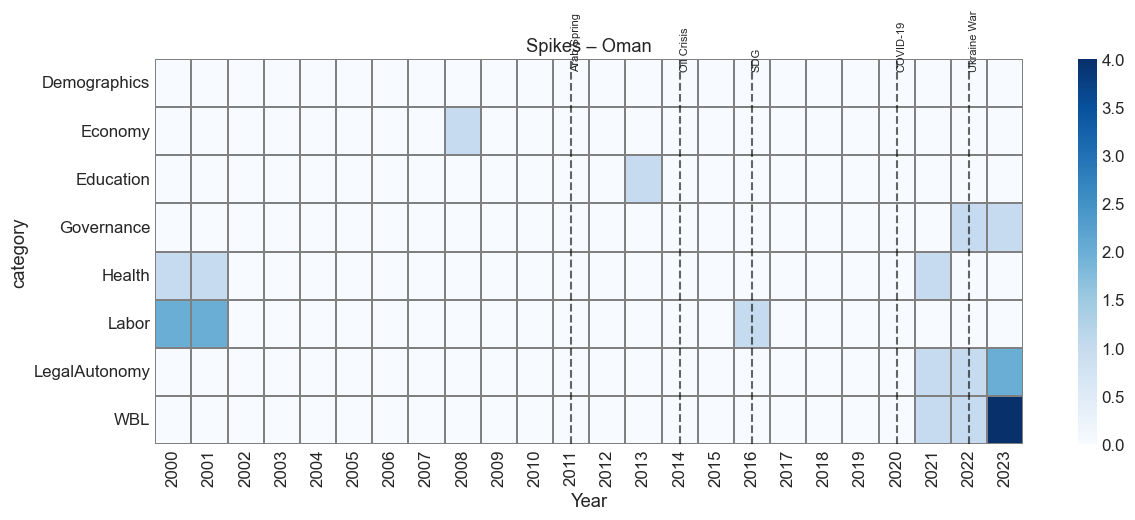

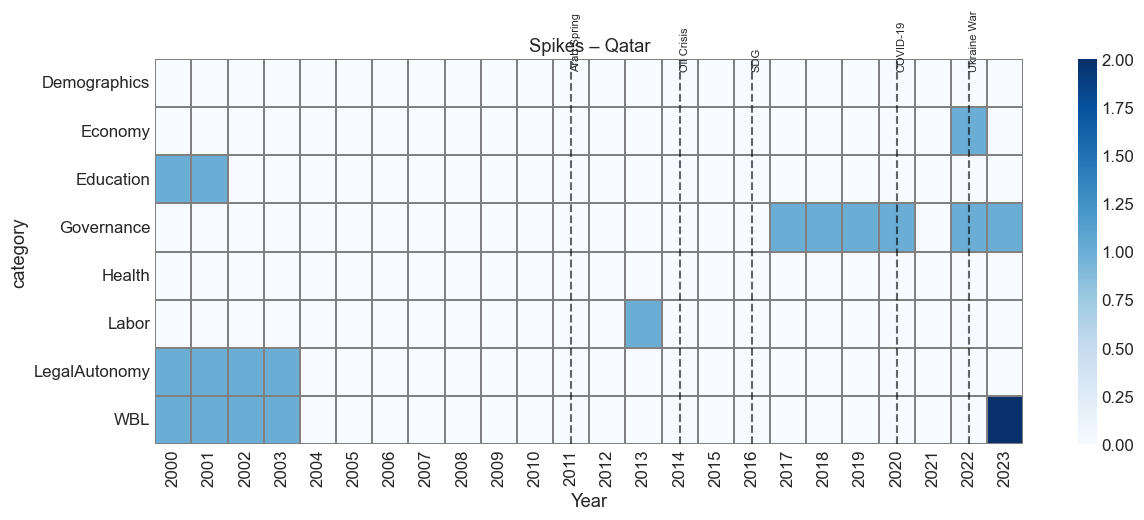

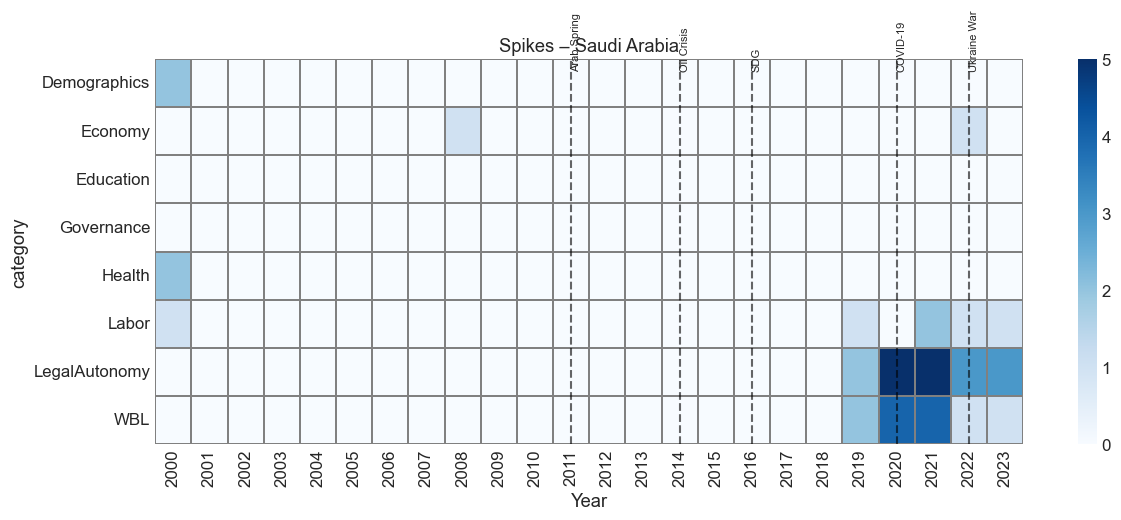

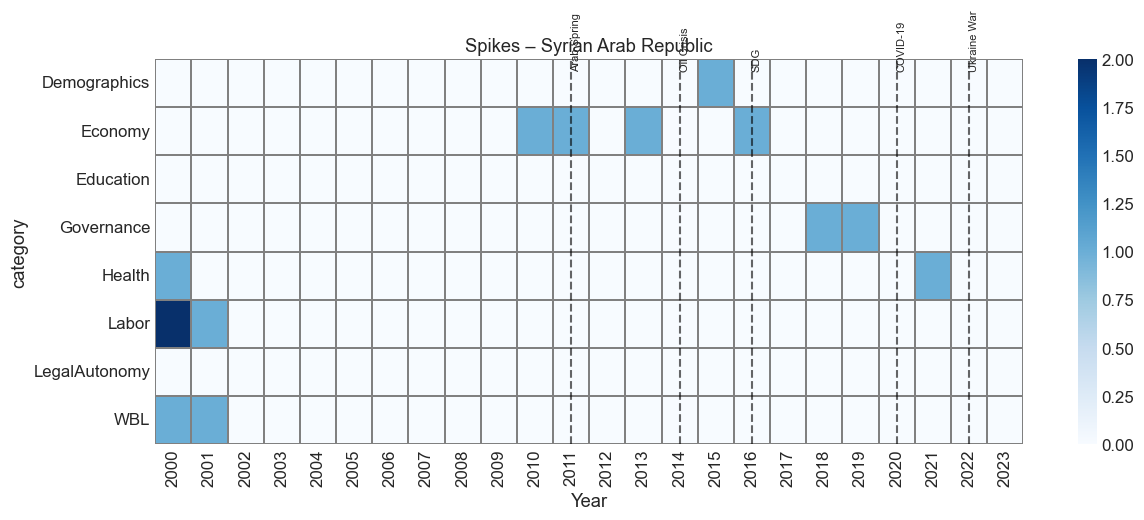

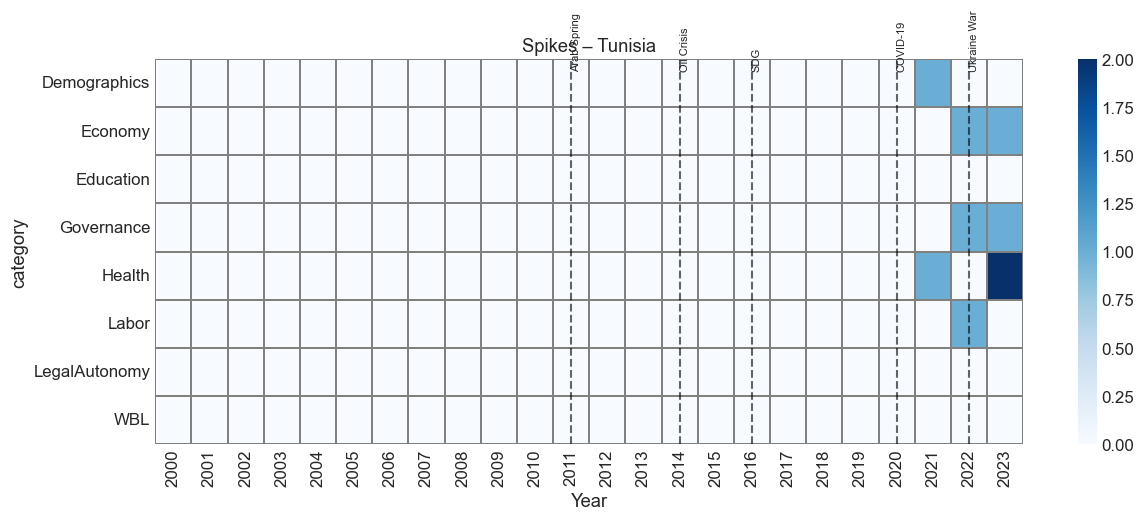

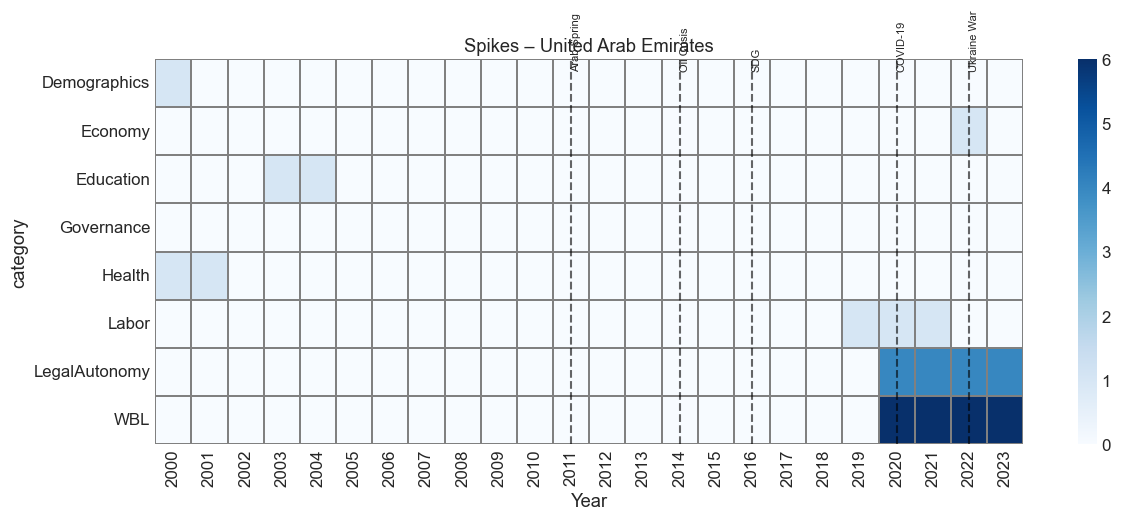

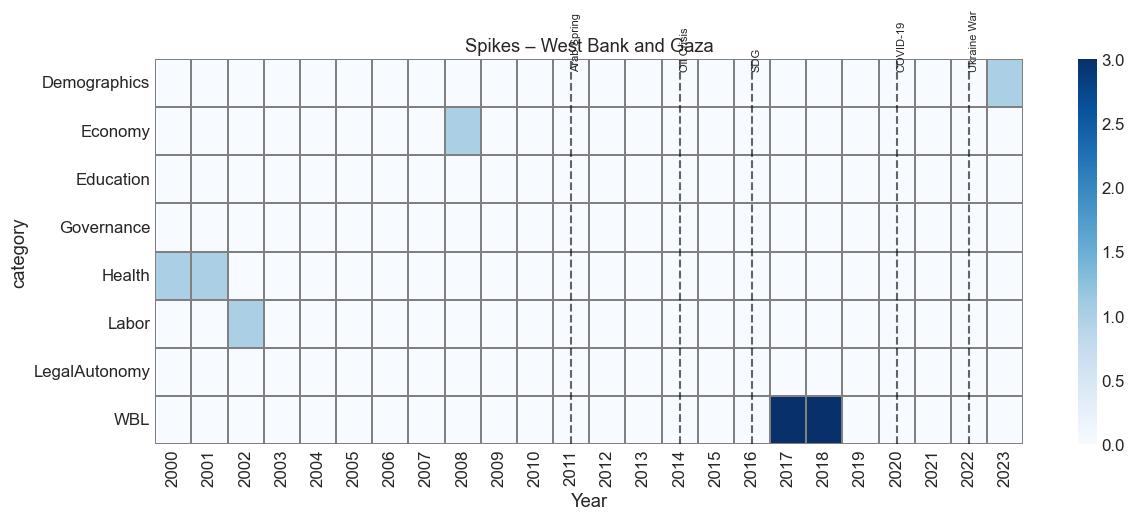

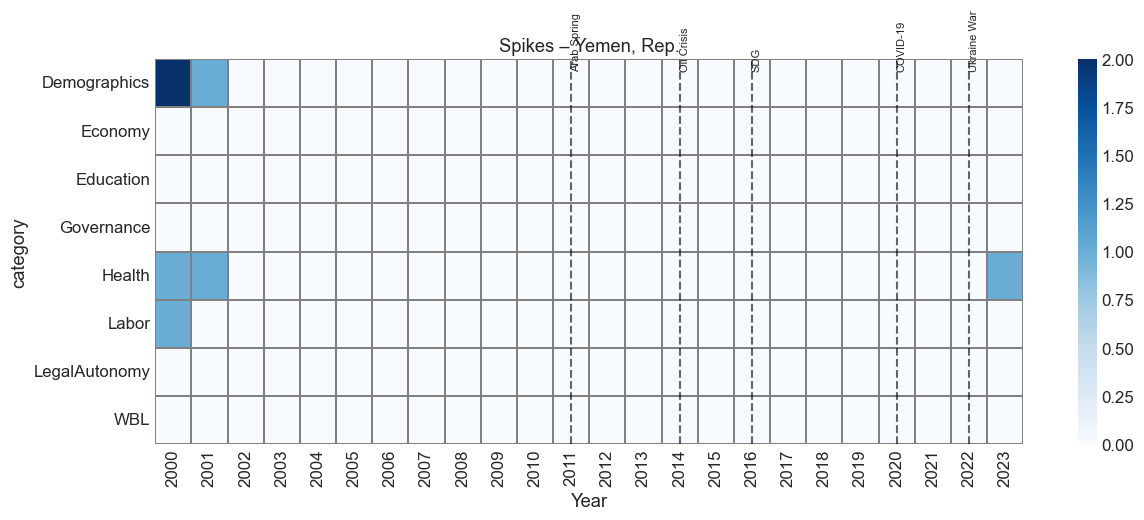

In [27]:
def plot_country_cat_year_heatmap(df, country, value_col="spike",
                                  title_prefix="Spikes",
                                  cmap="Blues", save_path=None):

    sub = df[df["country_name"] == country]
    if sub.empty:
        print("No data for", country)
        return

    mat = (
        sub.groupby(["category", "year"])[value_col]
        .sum()
        .reset_index()
        .pivot(index="category", columns="year", values=value_col)
        .fillna(0)
    )

    plt.figure(figsize=(14,5))
    ax = sns.heatmap(mat, cmap=cmap, linewidths=0.2, linecolor="grey")

    ax.set_title(f"{title_prefix} – {country}")
    ax.set_xlabel("Year")

    # Add event lines
    ymin, ymax = ax.get_ylim()
    years = mat.columns.values

    for y, label in SHORT_EVENTS.items():
        if y in years:
            xpos = np.where(years == y)[0][0] + 0.5
            ax.axvline(x=xpos, linestyle="--", color="black", alpha=0.6)
            ax.text(xpos, ymax + 0.2, label, rotation=90, fontsize=8)

    plt.show()

for country in df["country_name"].unique():
    plot_country_cat_year_heatmap(df, country, "spike", "Spikes", "Blues")


## 2.3 Event Timing Model: Before / During / After

In [28]:
def event_timing(row):
    """
    Returns: 'before', 'during', 'after', or None
    """
    event_years = list(SHORT_EVENTS.keys()) + list(MAJOR_EVENTS.keys())

    if row["year"] in event_years:
        return "during"

    # before = spike/dip the year prior to event
    if row["year"] + 1 in event_years:
        return "before"

    # after = spike/dip the year after event
    if row["year"] - 1 in event_years:
        return "after"

    return None

# Assign timing
df["event_timing"] = df.apply(event_timing, axis=1)


In [29]:
df["volatility_timing"] = df.apply(
    lambda r: r["event_timing"] if r["spike"]==1 or r["dip"]==1 else None,
    axis=1
)

df["volatility_timing"].value_counts()


volatility_timing
during    354
before     91
Name: count, dtype: int64

## 2.4 EVENT SENSITIVITY & CATEGORY RESPONSE

### Country Sensitivity Score

In [30]:
def compute_event_sensitivity(df):
    EVENT_YEARS = list(SHORT_EVENTS.keys())

    event_df = df[df["year"].isin(EVENT_YEARS)]

    sensitivity = (
        event_df.groupby("country_name")
        .agg(
            spikes=("spike", "sum"),
            dips=("dip", "sum"),
            total_indicators=("indicator_name", "nunique")
        )
        .reset_index()
    )

    sensitivity["sensitivity_score"] = (
        (sensitivity["spikes"] + sensitivity["dips"]) /
        sensitivity["total_indicators"]
    )

    return sensitivity.sort_values("sensitivity_score", ascending=False)

sensitivity_df = compute_event_sensitivity(df)
sensitivity_df.head()


,country_name,spikes,dips,total_indicators,sensitivity_score
15,United Arab Emirates,22,2,42,0.571429
12,Saudi Arabia,15,0,42,0.357143
1,Bahrain,12,2,42,0.333333
6,Kuwait,7,2,42,0.214286
7,Lebanon,8,1,42,0.214286


### Build the Category × Event Response Matrix

In [31]:
def category_event_matrix(df):

    EVENT_YEARS = {
        2011: "ArabSpring",
        2014: "OilCrisis",
        2019: "MENAProtests",
        2020: "COVID19",
    }

    rows = []

    for year, event in EVENT_YEARS.items():
        subset = df[df["year"] == year]

        stats = subset.groupby("category").agg(
            spikes=("spike", "sum"),
            dips=("dip", "sum")
        ).reset_index()

        stats["event"] = event
        stats["year"] = year
        rows.append(stats)

    return pd.concat(rows, ignore_index=True)

cat_event = category_event_matrix(df)
cat_event.head()


,category,spikes,dips,event,year
0,Demographics,0,0,ArabSpring,2011
1,Economy,2,0,ArabSpring,2011
2,Education,0,1,ArabSpring,2011
3,Governance,0,0,ArabSpring,2011
4,Health,0,1,ArabSpring,2011


In [32]:
def classify_response(r):
    if r["spikes"] == 0 and r["dips"] == 0:
        return "flat"
    if r["spikes"] > r["dips"] * 1.5:
        return "spike-heavy"
    if r["dips"] > r["spikes"] * 1.5:
        return "dip-heavy"
    return "mixed"

cat_event["response"] = cat_event.apply(classify_response, axis=1)

response_matrix = cat_event.pivot(index="category", columns="event", values="response")
response_matrix


event,ArabSpring,COVID19,MENAProtests,OilCrisis
category,,,,
Demographics,flat,spike-heavy,flat,flat
Economy,spike-heavy,dip-heavy,dip-heavy,flat
Education,dip-heavy,flat,flat,flat
Governance,flat,spike-heavy,spike-heavy,flat
Health,dip-heavy,dip-heavy,spike-heavy,flat
Labor,mixed,mixed,spike-heavy,flat
LegalAutonomy,flat,spike-heavy,spike-heavy,flat
WBL,flat,spike-heavy,spike-heavy,flat


## EVENT FLAGS

In [57]:
df.columns

Index(['country_name', 'year', 'value', 'indicator_id', 'indicator_name',
       'unit_type', 'source', 'source_reliable', 'region', 'category',
       'val_num', 'yoy_change', 'yoy_pct_change', 'yoy_pct_exists',
       'rolling_mean_3y', 'rolling_std_3y', 'rolling_mean_5y',
       'rolling_std_5y', 'cagr', 'spike', 'dip', 'outlier', 'trend_slope',
       'coef_variation', 'momentum', 'regional_deviation',
       'regional_deviation_std', 'event_global', 'event_country',
       'indicator_cluster', 'indicator_cluster_name', 'traj_cluster',
       'Cluster_Name', 'traj_cluster', 'Cluster', 'Cluster_Name_anomaly',
       'PC1', 'PC2', 'PC3', 'iso_raw_score', 'iso_anomaly_score', 'iso_label',
       'Anomaly_Driver', 'global_event_name', 'major_event_name',
       'short_event', 'country_event_name', 'has_spike_or_dip',
       'has_any_event', 'event_label_combined', 'has_anomaly', 'event_timing',
       'volatility_timing'],
      dtype='object')

In [58]:
df.head()

,country_name,year,value,indicator_id,indicator_name,unit_type,source,source_reliable,region,category,...,global_event_name,major_event_name,short_event,country_event_name,has_spike_or_dip,has_any_event,event_label_combined,has_anomaly,event_timing,volatility_timing
0,Algeria,2000,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,LegalAutonomy,...,,,,,0,0,,1,before,None
1,Algeria,2001,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,LegalAutonomy,...,,9/11 Attacks,,,0,1,9/11 Attacks,1,during,None
2,Algeria,2002,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,LegalAutonomy,...,,,,,0,0,,1,before,None
3,Algeria,2003,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,LegalAutonomy,...,,Iraq War Begins,,,0,1,Iraq War Begins,1,during,None
4,Algeria,2004,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,LegalAutonomy,...,Morocco Family Code Reform; Free Trade with US...,,,,0,1,Morocco Family Code Reform; Free Trade with US...,1,before,None


In [59]:
df["major_event_name"].value_counts()

major_event_name
                                                  3780
9/11 Attacks                                       756
Russia-Ukraine War / Global Inflation Surge        756
COVID Vaccination Rollouts / Beirut Recovery       756
COVID-19 Pandemic                                  756
Sudanese Revolution                                756
Global #MeToo Movement Peaks                       756
Qatar Diplomatic Crisis                            756
SDG Implementation Begins                          756
Yemen Civil War Escalates                          756
ISIS Emergence / Oil Crisis                        756
Egypt Military Coup                                756
Syrian Civil War Escalates                         756
Arab Spring                                        756
Tunisian Revolution                                756
Global Financial Crisis                            756
Lebanon-Israel War                                 756
Syrian Withdrawal from Lebanon                  

In [60]:
df['global_event_name'].value_counts()

global_event_name
                                                                                               9072
Morocco Family Code Reform; Free Trade with US; Earthquake; Migrant crisis                      756
Algeria National Reconciliation Referendum; EU agreement                                        756
Global Financial Crisis                                                                         756
Pre-Arab Spring crackdowns in Libya and Morocco; Lebanon border clashes                         756
Arab Spring; Oman Protests                                                                      756
Jordan elections and reform resistance; Saudi repression and migration diplomacy                756
Oil price crash                                                                                 756
Kafala reforms in Qatar; Tunisia resort attack; Algeria low oil prices                          756
UAE gender policy issues; Iraq Mosul offensive ; SDG rollout                      

In [61]:
df['country_event_name'].value_counts()

country_event_name
                                                                      15582
Ukraine War Global Impact                                               714
COVID-19 Pandemic                                                       672
Ceasefire Agreement; UN Peace Talks                                      42
Sousse Resort Attack; Terror Wave                                        42
Arab Spring Begins; Ben Ali Ousted                                       42
Liberalization Reforms; Aramco IPO                                       42
Oil Price Crash Begins                                                   42
Repression; Foreign Labor Policy Shift                                   42
FIFA World Cup                                                           42
Kafala Reform Starts; World Cup Prep                                     42
Tanker Incidents; Gulf Tensions                                          42
Protests over Jobs and Corruption                                    

In [65]:
df['short_event'].value_counts()

short_event
               14364
Arab Spring      756
Oil Crisis       756
SDG              756
COVID-19         756
Ukraine War      756
Name: count, dtype: int64

In [66]:
df_flags = df.copy()

event_cols = ["short_event", "country_event_name", "global_event_name", "major_event_name"]
for c in event_cols:
    if c not in df_flags.columns:
        raise KeyError(f"Missing column: {c}")

df_flags[event_cols].head()


,short_event,country_event_name,global_event_name,major_event_name
0,,,,
1,,,,9/11 Attacks
2,,,,
3,,,,Iraq War Begins
4,,,Morocco Family Code Reform; Free Trade with US...,


In [67]:
import re

def normalize_text(s: pd.Series) -> pd.Series:
    return (
        s.fillna("")
         .astype(str)
         .str.lower()
         .str.replace(r"\s+", " ", regex=True)
         .str.strip()
    )

df_flags["_short_event_txt"]   = normalize_text(df_flags["short_event"])
df_flags["_country_event_txt"] = normalize_text(df_flags["country_event_name"])
df_flags["_global_event_txt"]  = normalize_text(df_flags["global_event_name"])
df_flags["_major_event_txt"]   = normalize_text(df_flags["major_event_name"])


In [72]:
GLOBAL_CRISIS_EVENTS = {"covid-19", "ukraine war", "oil crisis"}
REGIONAL_CRISIS_EVENTS = {"arab spring"}
REFORM_EVENTS_SHORT = {"sdg"}  # treat SDG as reform window

df_flags["flag_global_crisis"] = df_flags["_short_event_txt"].isin(GLOBAL_CRISIS_EVENTS).astype(int)
df_flags["flag_regional_crisis"] = df_flags["_short_event_txt"].isin(REGIONAL_CRISIS_EVENTS).astype(int)

# SDG in short_event is a reform-period indicator
df_flags["flag_reform_period"] = df_flags["_short_event_txt"].isin(REFORM_EVENTS_SHORT).astype(int)


In [77]:
CONFLICT_PATTERN = re.compile(
    r"\b(?:"
    r"civil war|war begins|war escalates|war escalation|armed|insurg|"
    r"isis|mosul|offensive|military|intervention|border clashes|clashes|"
    r"occupation|gaddafi killed"
    r")\b"
)

CRISIS_PATTERN = re.compile(
    r"\b(?:"
    r"protest|unrest|uprising|repression|terror|attack|explosion|earthquake|"
    r"crisis|currency|austerity|corruption|economic tension|oil revenue drop|"
    r"pandemic|lockdown|inflation"
    r")\b"
)


REFORM_PATTERN = re.compile(
    r"\b(?:"
    r"reform|policy|liberalization|referendum|elections|agreement|"
    r"family code|kafala|sdg|free trade|eu association|labor policy"
    r")\b"
)


In [78]:
def has_pattern(text_series: pd.Series, pattern: re.Pattern) -> pd.Series:
    return text_series.str.contains(pattern, regex=True, na=False)

# conflict: country-level + major (reinforcement)
conflict_hit = (
    has_pattern(df_flags["_country_event_txt"], CONFLICT_PATTERN) |
    has_pattern(df_flags["_major_event_txt"], CONFLICT_PATTERN)
)

# crisis: country-level + global + major (broader)
crisis_hit = (
    has_pattern(df_flags["_country_event_txt"], CRISIS_PATTERN) |
    has_pattern(df_flags["_global_event_txt"], CRISIS_PATTERN) |
    has_pattern(df_flags["_major_event_txt"], CRISIS_PATTERN)
)

# reform: country-level + global + major + (already have SDG from short_event)
reform_hit = (
    has_pattern(df_flags["_country_event_txt"], REFORM_PATTERN) |
    has_pattern(df_flags["_global_event_txt"], REFORM_PATTERN) |
    has_pattern(df_flags["_major_event_txt"], REFORM_PATTERN)
)

df_flags["flag_country_conflict"] = conflict_hit.astype(int)
df_flags["flag_country_crisis"] = crisis_hit.astype(int)

# combine: SDG from short_event OR reform hits from text
df_flags["flag_reform_period"] = (
    (df_flags["flag_reform_period"] == 1) | reform_hit
).astype(int)


In [79]:
flag_cols = [
    "flag_global_crisis",
    "flag_regional_crisis",
    "flag_country_conflict",
    "flag_country_crisis",
    "flag_reform_period"
]

df_flags[flag_cols].sum().sort_values(ascending=False)


flag_country_crisis      7014
flag_country_conflict    3948
flag_reform_period       3906
flag_global_crisis       2268
flag_regional_crisis      756
dtype: int64

In [80]:
pd.crosstab(df_flags["flag_country_conflict"], df_flags["flag_country_crisis"])


flag_country_crisis,0,1
flag_country_conflict,,
0,9450,4746
1,1680,2268


In [82]:
df_flags.loc[df_flags["flag_country_conflict"] == 1, ["country_event_name", "major_event_name"]].head(10)



,country_event_name,major_event_name
3,,Iraq War Begins
12,,Syrian Civil War Escalates
13,,Egypt Military Coup
14,,ISIS Emergence / Oil Crisis
15,Oil Revenue Drop; Economic Tension,Yemen Civil War Escalates
27,,Iraq War Begins
36,,Syrian Civil War Escalates
37,,Egypt Military Coup
38,,ISIS Emergence / Oil Crisis
39,Oil Revenue Drop; Economic Tension,Yemen Civil War Escalates


In [83]:
df_flags.loc[df_flags["flag_reform_period"] == 1, ["short_event", "country_event_name", "global_event_name", "major_event_name"]].head(10)

,short_event,country_event_name,global_event_name,major_event_name
4,,,Morocco Family Code Reform; Free Trade with US...,
5,,National Reconciliation Referendum; EU Associa...,Algeria National Reconciliation Referendum; EU...,Syrian Withdrawal from Lebanon
13,,,Jordan elections and reform resistance; Saudi ...,Egypt Military Coup
15,,Oil Revenue Drop; Economic Tension,Kafala reforms in Qatar; Tunisia resort attack...,Yemen Civil War Escalates
16,SDG,,UAE gender policy issues; Iraq Mosul offensive...,SDG Implementation Begins
28,,,Morocco Family Code Reform; Free Trade with US...,
29,,National Reconciliation Referendum; EU Associa...,Algeria National Reconciliation Referendum; EU...,Syrian Withdrawal from Lebanon
37,,,Jordan elections and reform resistance; Saudi ...,Egypt Military Coup
39,,Oil Revenue Drop; Economic Tension,Kafala reforms in Qatar; Tunisia resort attack...,Yemen Civil War Escalates
40,SDG,,UAE gender policy issues; Iraq Mosul offensive...,SDG Implementation Begins


In [84]:
df_flags.head()

,country_name,year,value,indicator_id,indicator_name,unit_type,source,source_reliable,region,category,...,volatility_timing,_short_event_txt,_country_event_txt,_global_event_txt,_major_event_txt,flag_global_crisis,flag_regional_crisis,flag_reform_period,flag_country_conflict,flag_country_crisis
0,Algeria,2000,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,LegalAutonomy,...,None,,,,,0,0,0,0,0
1,Algeria,2001,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,LegalAutonomy,...,None,,,,9/11 attacks,0,0,0,0,0
2,Algeria,2002,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,LegalAutonomy,...,None,,,,,0,0,0,0,0
3,Algeria,2003,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,LegalAutonomy,...,None,,,,iraq war begins,0,0,0,1,0
4,Algeria,2004,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,LegalAutonomy,...,None,,,morocco family code reform; free trade with us...,,0,0,1,0,1


In [85]:
# Adjust these keys to match your actual column names
KEYS = ["country_name", "year"]

missing_keys = [k for k in KEYS if k not in df_flags.columns]
if missing_keys:
    raise KeyError(f"Your df is missing merge keys: {missing_keys}")

event_flags_table = df_flags[KEYS + flag_cols].drop_duplicates()

event_flags_table.head()


,country_name,year,flag_global_crisis,flag_regional_crisis,flag_country_conflict,flag_country_crisis,flag_reform_period
0,Algeria,2000,0,0,0,0,0
1,Algeria,2001,0,0,0,0,0
2,Algeria,2002,0,0,0,0,0
3,Algeria,2003,0,0,1,0,0
4,Algeria,2004,0,0,0,1,1


In [86]:
conditions = [
    event_flags_table['flag_country_conflict']==1,
    event_flags_table['flag_country_crisis'] ==1,
    event_flags_table['flag_reform_period'] ==1,
]

choices = ['conflict','crisis','reform']

event_flags_table['event_type_primary'] = np.select(
    conditions,
    choices,
    default='none'
)

In [89]:
event_flags_table.groupby('year')['event_type_primary'].value_counts()


year  event_type_primary
2000  none                  18
2001  none                  18
2002  none                  18
2003  conflict              18
2004  crisis                18
2005  reform                18
2006  none                  18
2007  none                  18
2008  crisis                18
2009  none                  18
2010  none                  16
      conflict               1
      crisis                 1
2011  none                  15
      conflict               2
      crisis                 1
2012  conflict              18
2013  conflict              18
2014  conflict              18
2015  conflict              18
2016  reform                17
      conflict               1
2017  crisis                18
2018  none                  18
2019  none                  13
      crisis                 3
      reform                 2
2020  crisis                18
2021  none                  18
2022  crisis                18
2023  crisis                18
Name: count, d

In [90]:
pd.crosstab(
    event_flags_table["flag_country_conflict"],
    event_flags_table["event_type_primary"]
)


event_type_primary,conflict,crisis,none,reform
flag_country_conflict,,,,
0,0,113,188,37
1,94,0,0,0


In [91]:
event_flags_table[[
    "flag_country_conflict",
    "flag_country_crisis",
    "flag_reform_period"
]].mean().sort_values(ascending=False)


flag_country_crisis      0.386574
flag_country_conflict    0.217593
flag_reform_period       0.215278
dtype: float64

In [92]:
pd.crosstab(
    event_flags_table["flag_country_conflict"],
    event_flags_table["flag_country_crisis"]
)


flag_country_crisis,0,1
flag_country_conflict,,
0,225,113
1,40,54


In [97]:
df_flags['indicator_name'].to_list()

['A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
 'A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
 'A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
 'A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
 'A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
 'A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
 'A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
 'A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
 'A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
 'A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
 'A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
 'A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
 'A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
 'A woman ca

In [102]:
df_ind = df_flags[df_flags['indicator_name']=='Employment to population ratio, 15+, female (%) (modeled ILO estimate)']


df_ind.groupby("flag_country_crisis")["value"].agg(
    ["mean", "std", "median"]
)


,mean,std,median
flag_country_crisis,,,
0,21.947962,13.147716,18.102
1,22.407222,14.470299,18.352


In [103]:
df_ind.groupby("flag_country_conflict")["value"].agg(
    ["mean", "std", "median"]
)


,mean,std,median
flag_country_conflict,,,
0,22.087660,13.685297,18.1445
1,22.261564,13.638137,18.5610


In [107]:
event_flags_table[event_flags_table['year']==2011].head()

,country_name,year,flag_global_crisis,flag_regional_crisis,flag_country_conflict,flag_country_crisis,flag_reform_period,event_type_primary
11,Algeria,2011,0,1,0,0,0,none
1019,Bahrain,2011,0,1,1,0,0,conflict
2027,"Egypt, Arab Rep.",2011,0,1,0,0,0,none
3035,"Iran, Islamic Rep.",2011,0,1,0,0,0,none
4043,Iraq,2011,0,1,0,0,0,none


In [ ]:
event_flags_table.to_csv("data/event_flags_country_year.csv")


# PHASE 3

### 3.1 Country-level summaries & event–anomaly matrix

In [33]:
# Helper: clean & deduplicate label strings
def _combine_labels(series):
    labels = []
    for v in series:
        if pd.isna(v):
            continue
        text = str(v).strip()
        if text and text.lower() != "none":
            for p in text.split(";"):
                p = p.strip()
                if p and p not in labels:
                    labels.append(p)
    return "; ".join(labels)


def build_country_year_summary(df):
    """
    One row per (country, year) with:
    - spikes / dips
    - #categories affected
    - event flags + labels
    - volatility timing distribution
    - dominant direction label
    """

    grouped = (
        df.groupby(["country_name", "year"])
          .agg(
              spikes=("spike", "sum"),
              dips=("dip", "sum"),
              categories_affected=("category", "nunique"),
              has_event=("has_any_event", "max"),
              event_labels=("event_label_combined", _combine_labels),
              timing_before=("volatility_timing", lambda x: (x == "before").sum()),
              timing_during=("volatility_timing", lambda x: (x == "during").sum()),
              timing_after=("volatility_timing", lambda x: (x == "after").sum()),
          )
          .reset_index()
    )

    # Dominant direction per year
    def _direction(row):
        if row["spikes"] == 0 and row["dips"] == 0:
            return "flat"
        if row["spikes"] > row["dips"] * 1.5:
            return "spike-heavy"
        if row["dips"] > row["spikes"] * 1.5:
            return "dip-heavy"
        return "mixed"

    grouped["direction"] = grouped.apply(_direction, axis=1)

    # Is this year an "event-aligned anomaly"?
    grouped["event_aligned_anomaly"] = (
        (grouped["has_event"] == 1) & ((grouped["spikes"] > 0) | (grouped["dips"] > 0))
    ).astype(int)

    return grouped


country_year_summary = build_country_year_summary(df)
country_year_summary.head()


,country_name,year,spikes,dips,categories_affected,has_event,event_labels,timing_before,timing_during,timing_after,direction,event_aligned_anomaly
0,Algeria,2000,4,4,8,0,,8,0,0,mixed,0
1,Algeria,2001,3,0,8,1,9/11 Attacks,0,3,0,spike-heavy,1
2,Algeria,2002,0,0,8,0,,0,0,0,flat,0
3,Algeria,2003,0,0,8,1,Iraq War Begins,0,0,0,flat,0
4,Algeria,2004,0,0,8,1,Morocco Family Code Reform; Free Trade with US...,0,0,0,flat,0


In [34]:
country_year_summary.to_csv(f"{OUTPUT_DIR}/Countrty_Year_Volatility_Summary.csv")

### 3.1.2 Country × Category summary

In [35]:
def build_country_category_summary(df):
    """
    One row per (country, category) with total spikes/dips and net direction.
    """

    grouped = (
        df.groupby(["country_name", "category"])
          .agg(
              total_spikes=("spike", "sum"),
              total_dips=("dip", "sum"),
              years_affected=("year", "nunique"),
          )
          .reset_index()
    )

    def _cat_direction(r):
        if r["total_spikes"] == 0 and r["total_dips"] == 0:
            return "stable"
        if r["total_spikes"] > r["total_dips"] * 1.5:
            return "reform / spike-driven"
        if r["total_dips"] > r["total_spikes"] * 1.5:
            return "crisis / dip-driven"
        return "mixed"

    grouped["direction"] = grouped.apply(_cat_direction, axis=1)

    return grouped


country_category_summary = build_country_category_summary(df)
country_category_summary.head()


,country_name,category,total_spikes,total_dips,years_affected,direction
0,Algeria,Demographics,1,0,24,reform / spike-driven
1,Algeria,Economy,2,0,24,reform / spike-driven
2,Algeria,Education,1,0,24,reform / spike-driven
3,Algeria,Governance,1,1,24,mixed
4,Algeria,Health,2,2,24,mixed


In [36]:
country_category_summary.to_csv(f"{OUTPUT_DIR}/Country_Category_Volatility_Summary.csv")

### 3.1.3 Event–Anomaly Matrix (for the thesis & cross-model integration)

In [37]:
df.columns

Index(['country_name', 'year', 'value', 'indicator_id', 'indicator_name',
       'unit_type', 'source', 'source_reliable', 'region', 'category',
       'val_num', 'yoy_change', 'yoy_pct_change', 'yoy_pct_exists',
       'rolling_mean_3y', 'rolling_std_3y', 'rolling_mean_5y',
       'rolling_std_5y', 'cagr', 'spike', 'dip', 'outlier', 'trend_slope',
       'coef_variation', 'momentum', 'regional_deviation',
       'regional_deviation_std', 'event_global', 'event_country',
       'indicator_cluster', 'indicator_cluster_name', 'traj_cluster',
       'Cluster_Name', 'traj_cluster', 'Cluster', 'Cluster_Name_anomaly',
       'PC1', 'PC2', 'PC3', 'iso_raw_score', 'iso_anomaly_score', 'iso_label',
       'Anomaly_Driver', 'global_event_name', 'major_event_name',
       'short_event', 'country_event_name', 'has_spike_or_dip',
       'has_any_event', 'event_label_combined', 'has_anomaly', 'event_timing',
       'volatility_timing'],
      dtype='object')

In [38]:
df['Cluster_Name'].value_counts()

Cluster_Name
Education-Led Social Improvers    9072
Steady Moderate Improvers         4032
Steady Reformers                  2016
Morocco                           1008
UAE                               1008
Palestine                         1008
Name: count, dtype: int64

In [39]:
def build_event_anomaly_matrix(df, country_year_summary):
    """
    Matrix restricted to years that have:
    - an event, AND
    - at least one spike or dip
    """

    mat = country_year_summary.copy()
    mat = mat[mat["event_aligned_anomaly"] == 1]

    # Add structural cluster + anomaly driver from df/anomaly_df
    meta = (
        df[["country_name", "Cluster_Name", "traj_cluster",
             "iso_label", "Anomaly_Driver"]]
        .drop_duplicates()
    )

    mat = mat.merge(meta, on="country_name", how="left")

    # Order columns nicely
    cols = [
        "country_name", "Cluster_Name", "traj_cluster_name",
        "year", "spikes", "dips", "direction",
        "categories_affected",
        "has_event", "event_labels",
        "timing_before", "timing_during", "timing_after",
        "iso_label", "Anomaly_Driver",
    ]

    mat = mat[[c for c in cols if c in mat.columns]]

    return mat


event_anomaly_matrix = build_event_anomaly_matrix(df, country_year_summary)
event_anomaly_matrix.head()


,country_name,Cluster_Name,year,spikes,dips,direction,categories_affected,has_event,event_labels,timing_before,timing_during,timing_after,iso_label,Anomaly_Driver
0,Algeria,Education-Led Social Improvers,2001,3,0,spike-heavy,8,1,9/11 Attacks,0,3,0,0,PC3
1,Algeria,Education-Led Social Improvers,2005,1,0,spike-heavy,8,1,Syrian Withdrawal from Lebanon; Algeria Nation...,0,1,0,0,PC3
2,Algeria,Education-Led Social Improvers,2011,1,0,spike-heavy,8,1,Arab Spring; Oman Protests,0,1,0,0,PC3
3,Algeria,Education-Led Social Improvers,2012,0,1,dip-heavy,8,1,Syrian Civil War Escalates,0,1,0,0,PC3
4,Algeria,Education-Led Social Improvers,2015,1,0,spike-heavy,8,1,Yemen Civil War Escalates; Kafala reforms in Q...,0,1,0,0,PC3


In [40]:
event_anomaly_matrix.to_csv(OUTPUT_DIR / "event_anomaly_matrix.csv", index=False)


### 3.2 Country narratives (event–volatility–cluster story)

In [41]:
# If you ran compute_event_sensitivity(df) in Phase 2:
try:
    sensitivity_lookup = (
        sensitivity_df[["country_name", "sensitivity_score"]]
        .set_index("country_name")["sensitivity_score"]
        .to_dict()
    )
except NameError:
    sensitivity_lookup = {}


In [42]:
def generate_country_narrative(
    df,
    country,
    country_year_summary,
    country_category_summary,
    event_anomaly_matrix,
    sensitivity_lookup=None,
):
    """
    Returns a multi-paragraph narrative string for one country.
    """

    dfc = df[df["country_name"] == country]
    if dfc.empty:
        return f"No data for {country}."

    # --- basic meta ---
    meta = (
        dfc[["Cluster_Name", "traj_cluster", "iso_label", "Anomaly_Driver"]]
        .drop_duplicates()
        .iloc[0]
    )
    #cluster_label = meta.get("Cluster_Name", "Unknown cluster")
    traj_label = meta.get("Cluster_Name", "")
    anomaly_label = meta.get("iso_label", "")
    anomaly_driver = meta.get("Anomaly_Driver", "")

    # --- volatility peaks ---
    cys = country_year_summary[country_year_summary["country_name"] == country]
    if not cys.empty:
        peak_spike_year = cys.loc[cys["spikes"].idxmax(), "year"]
        peak_dip_year = cys.loc[cys["dips"].idxmax(), "year"]
    else:
        peak_spike_year = peak_dip_year = None

    # --- key events aligned ---
    aligned = event_anomaly_matrix[event_anomaly_matrix["country_name"] == country]
    key_event_lines = []
    for _, row in aligned.sort_values("year").iterrows():
        label = row.get("event_labels", "")
        direction = row.get("direction", "")
        year = int(row["year"])
        key_event_lines.append(f"- {year}: {direction} volatility during **{label}**")

    # --- category directions ---
    ccat = country_category_summary[country_category_summary["country_name"] == country]
    ccat = ccat.sort_values("total_spikes", ascending=False)
    top_cats = ccat.head(4)

    cat_lines = []
    for _, row in top_cats.iterrows():
        cat = row["category"]
        spikes = int(row["total_spikes"])
        dips = int(row["total_dips"])
        direction = row["direction"]
        cat_lines.append(
            f"- **{cat}**: {direction} (spikes={spikes}, dips={dips})"
        )

    # --- sensitivity ---
    sens_text = ""
    if sensitivity_lookup and country in sensitivity_lookup:
        s = sensitivity_lookup[country]
        if s >= np.quantile(list(sensitivity_lookup.values()), 0.66):
            level = "high"
        elif s <= np.quantile(list(sensitivity_lookup.values()), 0.33):
            level = "low"
        else:
            level = "medium"
        sens_text = f"{country} shows **{level} event sensitivity** (score ≈ {s:.3f})."

    # --- build narrative ---
    parts = []

    parts.append(
        f"{country} belongs to trajectory cluster **{traj_label}**"
        + ", indicating a characteristic long-term development pattern."
    )

    if anomaly_label or anomaly_driver:
        parts.append(
            f"The anomaly model labels this country as **{anomaly_label}**, "
            f"with anomaly dynamics primarily driven by **{anomaly_driver}**."
        )

    if peak_spike_year is not None and peak_dip_year is not None:
        parts.append(
            f"Peak volatility occurs in **{peak_spike_year}** for spikes and "
            f"**{peak_dip_year}** for dips, marking the years of most intense change."
        )

    if sens_text:
        parts.append(sens_text)

    if key_event_lines:
        parts.append(
            "Key years where **event shocks align with volatility anomalies** include:\n"
            + "\n".join(key_event_lines)
        )
    else:
        parts.append(
            "No major global or regional events in the dictionary coincide with strong "
            "spike/dip patterns for this country."
        )

    if cat_lines:
        parts.append(
            "Across indicator categories, volatility is distributed as follows:\n"
            + "\n".join(cat_lines)
        )

    parts.append(
        "Overall, the combination of structural cluster membership, anomaly label, "
        "and event-aligned volatility suggests a pattern where we must distinguish "
        "between genuine crisis-induced dips, reform-driven spikes, and long-term "
        "structural change."
    )

    return "\n\n".join(parts)


In [43]:
country_narratives = {}

for c in sorted(df["country_name"].unique()):
    country_narratives[c] = generate_country_narrative(
        df,
        c,
        country_year_summary,
        country_category_summary,
        event_anomaly_matrix,
        sensitivity_lookup=sensitivity_lookup,
    )

# Quick check
print(country_narratives[list(country_narratives.keys())[0]][:1200])


Algeria belongs to trajectory cluster **Education-Led Social Improvers**, indicating a characteristic long-term development pattern.

The anomaly model labels this country as **0**, with anomaly dynamics primarily driven by **PC3**.

Peak volatility occurs in **2000** for spikes and **2000** for dips, marking the years of most intense change.

Algeria shows **low event sensitivity** (score ≈ 0.071).

Key years where **event shocks align with volatility anomalies** include:
- 2001: spike-heavy volatility during **9/11 Attacks**
- 2005: spike-heavy volatility during **Syrian Withdrawal from Lebanon; Algeria National Reconciliation Referendum; EU agreement; National Reconciliation Referendum; EU Association Agreement**
- 2011: spike-heavy volatility during **Arab Spring; Oman Protests**
- 2012: dip-heavy volatility during **Syrian Civil War Escalates**
- 2015: spike-heavy volatility during **Yemen Civil War Escalates; Kafala reforms in Qatar; Tunisia resort attack; Algeria low oil prices;

In [44]:
narrative_df = pd.DataFrame(
    [{"country_name": c, "narrative": txt} for c, txt in country_narratives.items()]
)
narrative_df.to_csv(OUTPUT_DIR / "country_narratives.csv", index=False)


## A Combined Country Report

### 1- Imports & Global Settings

In [45]:
from reportlab.platypus import (
    SimpleDocTemplate, Table, TableStyle,
    Paragraph, Spacer, Image, PageBreak
)
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
import os

styles = getSampleStyleSheet()
NORMAL = styles["Normal"]
HEADER = styles["Heading5"]
TITLE = styles["Title"]
H1 = styles["Heading1"]
H2 = styles["Heading2"]
PAGE_WIDTH = A4[0] - 80   # 80 = left + right margins (40 each)



In [46]:
country_cluster_label = (
    df[["country_name", "Cluster_Name"]]
    .drop_duplicates()
    .set_index("country_name")["Cluster_Name"]
    .to_dict()
)


### 2- Helper Utilities

In [47]:
def clean_event_string(text, max_items=2):
    if pd.isna(text) or str(text).strip() == "":
        return ""
    parts = [p.strip() for p in str(text).split(";") if p.strip()]
    unique = list(dict.fromkeys(parts))
    if len(unique) <= max_items:
        return ", ".join(unique)
    return ", ".join(unique[:max_items]) + " …"


In [48]:
def get_column_widths(df):
    """
    Assign semantic column widths:
    - numeric columns → narrow
    - event_labels → wide
    - everything else → medium
    """
    
    PAGE_WIDTH = A4[0] - 80  # 40 left + 40 right margins
    
    narrow = 0.7
    medium = 1.0
    wide = 2.5
    
    weights = []
    
    for col in df.columns:
        if col in ["event_labels", "global_event_clean", "country_event_clean", "short_event_clean"]:
            weights.append(wide)
        elif col in ["year", "spike", "dip", "categories_affected",
                     "timing_before", "timing_during", "timing_after",
                     "has_event"]:
            weights.append(narrow)
        else:
            weights.append(medium)
    
    total_weight = sum(weights)
    col_widths = [(w / total_weight) * PAGE_WIDTH for w in weights]
    
    return col_widths


In [49]:
def df_to_platypus_table(df, long_text_cols=None):
    if long_text_cols is None:
        long_text_cols = []

    col_widths = get_column_widths(df)

    data = []

    # Header row
    header_row = [
        Paragraph(f"<b>{col}</b>", HEADER)
        for col in df.columns
    ]
    data.append(header_row)

    # Body rows
    for _, row in df.iterrows():
        row_cells = []
        for col in df.columns:
            val = "" if pd.isna(row[col]) else row[col]

            # Always wrap text
            row_cells.append(Paragraph(str(val), NORMAL))

        data.append(row_cells)

    table = Table(data, colWidths=col_widths, repeatRows=1)

    style = TableStyle([
        ("GRID", (0, 0), (-1, -1), 0.25, colors.grey),
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
        ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ])

    # stripe
    for i in range(1, len(data)):
        bg = colors.whitesmoke if (i % 2 == 0) else colors.white
        style.add("BACKGROUND", (0, i), (-1, i), bg)

    table.setStyle(style)

    return table




### 3- Plot Generators (Saved Silently)

In [50]:
def save_country_heatmap(df, country, value_col, cmap, save_path, title_prefix):
    fig, ax = plt.subplots(figsize=(18, 6))
    df_country = df[df["country_name"] == country]

    pivot = df_country.pivot_table(
        index="category",
        columns="year",
        values=value_col,
        aggfunc="sum",
        fill_value=0
    )

    sns.heatmap(
        pivot,
        cmap=cmap,
        linewidths=0.3,
        linecolor="white",
        ax=ax,
        cbar_kws={"label": value_col},
        vmin=0
    )

    ax.set_title(f"{title_prefix} — {country}", fontsize=14)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)



In [51]:
def save_country_trendlines(df, country, save_total, save_cat_prefix):
    dfc = df[df["country_name"] == country]

    yearly = dfc.groupby("year").agg(
        spikes=("spike","sum"),
        dips=("dip","sum")
    ).reset_index()

    # Total trends
    fig, ax = plt.subplots(figsize=(14,5))
    ax.plot(yearly["year"], yearly["spikes"], label="Spikes", color="blue")
    ax.plot(yearly["year"], yearly["dips"], label="Dips", color="red")
    ax.set_title(f"Total Spikes & Dips — {country}")
    ax.legend()

    fig.savefig(save_total, dpi=300, bbox_inches="tight")
    plt.close(fig)

    # Category trends
    for cat in ["Governance", "WBL", "Health", "Labor","LegalAutonomy"]:
        dfc_cat = dfc[dfc["category"] == cat]
        yearly_cat = dfc_cat.groupby("year")[["spike","dip"]].sum().reset_index()

        fig, ax = plt.subplots(figsize=(14,5))
        ax.plot(yearly_cat["year"], yearly_cat["spike"], color="blue", label="Spikes")
        ax.plot(yearly_cat["year"], yearly_cat["dip"], color="red", label="Dips")
        ax.set_title(f"{cat} Volatility — {country}")
        ax.legend()

        fig.savefig(f"{save_cat_prefix}_{cat}.png", dpi=300, bbox_inches="tight")
        plt.close(fig)



### 4- Summary Table Builders

In [52]:
def build_country_summary_df(country):
    return country_year_summary[
        country_year_summary["country_name"] == country
    ].sort_values("year")


In [53]:
def build_category_summary_df(country):
    return country_category_summary[
        country_category_summary["country_name"] == country
    ].sort_values("total_spikes", ascending=False)


### 5- Country Narrative Builder

In [54]:
def narrative_for(country):
    return country_narratives.get(country, "Narrative not found.")


### 6- Premium PDF Creator (Platypus)

In [55]:
def create_country_pdf_platypus(
    country,
    narrative,
    summary_df,
    category_df,
    event_matrix_df,
    spikes_img,
    dips_img,
    trends_total_img,
    trends_cat_prefix,
    save_path
):

    doc = SimpleDocTemplate(save_path, pagesize=A4,
                            leftMargin=40, rightMargin=40,
                            topMargin=50, bottomMargin=40)

    story = []

    # Page 1 — Title
    story.append(Paragraph(f"{country} — Shock & Reform Dynamics Report", styles["Title"]))
    story.append(Paragraph(
        f"Trajectory Cluster: <b>{country_cluster_label.get(country, 'Unknown')}</b>",
        H2
    ))
    story.append(PageBreak())

    # Page 2 — Narrative
    story.append(Paragraph("Narrative Summary", H1))
    for para in narrative.split("\n\n"):
        story.append(Paragraph(para, NORMAL))
        story.append(Spacer(1, 8))
    story.append(PageBreak())

    # Page 3 — Summary Table
    story.append(Paragraph("Event–Spike–Dip Summary", H1))
    story.append(df_to_platypus_table(
        summary_df,
        long_text_cols=[
            "event_labels",
            "global_event_clean",
            "country_event_clean",
            "short_event_clean"
        ]
    ))
    story.append(PageBreak())

    # Category Summary
    story.append(Paragraph("Category-Level Volatility Profile", H1))
    story.append(df_to_platypus_table(category_df))
    story.append(PageBreak())
    
    # Page 5 — Event-Anomaly Matrix
    story.append(Paragraph("Event–Anomaly Alignment Matrix", H1))
    story.append(df_to_platypus_table(
        event_matrix_df,
        long_text_cols=["event_labels"]
    ))
    story.append(PageBreak())

    # Heatmaps
    story.append(Paragraph("Spikes Heatmap", H1))
    story.append(Image(spikes_img, width=480, height=240))
    story.append(PageBreak())

    story.append(Paragraph("Dips Heatmap", H1))
    story.append(Image(dips_img, width=480, height=240))
    story.append(PageBreak())

    # Total Trends
    story.append(Paragraph("Total Volatility Trends", H1))
    story.append(Image(trends_total_img, width=480, height=240))
    story.append(PageBreak())

    # Category Trends
    for cat in ["Governance", "WBL", "Health", "Labor","LegalAutonomy"]:
        img = f"{trends_cat_prefix}_{cat}.png"
        if os.path.exists(img):
            story.append(Paragraph(f"{cat} Volatility Trends", H1))
            story.append(Image(img, width=480, height=240))
            story.append(PageBreak())

    doc.build(story)


### 7-Full Pipeline Loop

In [ ]:
PDF_DIR = os.path.join(OUTPUT_DIR, "country_reports_final")
os.makedirs(PDF_DIR, exist_ok=True)


def abs_path(path):
    return os.path.abspath(path)

countries = sorted(df["country_name"].unique())

for country in countries:
    print(f"Generating report for {country}...")
    
    narrative = narrative_for(country)
    summary_df = build_country_summary_df(country)
    category_df = build_category_summary_df(country)
    event_matrix_df = event_anomaly_matrix[event_anomaly_matrix["country_name"] == country]
    

    # File paths
    
    spikes_img = abs_path(os.path.join(OUTPUT_DIR, f"{country}_spikes.png"))
    dips_img = abs_path(os.path.join(OUTPUT_DIR, f"{country}_dips.png"))
    trends_total_img = abs_path(os.path.join(OUTPUT_DIR, f"{country}_trends.png"))
    trends_cat_prefix = abs_path(os.path.join(OUTPUT_DIR, f"{country}_trends_cat"))
    
    save_country_heatmap(df, country, "spike", "Blues", spikes_img, "Spikes Heatmap")
    save_country_heatmap(df, country, "dip", "Reds", dips_img, "Dips Heatmap")
    save_country_trendlines(df, country, trends_total_img, trends_cat_prefix)

    
    
    pdf_path = abs_path(os.path.join(PDF_DIR, f"{country}_Report.pdf"))


    create_country_pdf_platypus(
        country,
        narrative,
        summary_df,
        category_df,
        event_matrix_df,
        spikes_img,
        dips_img,
        trends_total_img,
        trends_cat_prefix,
        pdf_path
    )

    print(f"Saved → {pdf_path}\n")
